In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/raimamunir/household/household_power_consumption.csv")

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [5]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

In [10]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [11]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,NaN,NaN,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,NaN,NaN,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,NaN,NaN,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,NaN,NaN,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,NaN,NaN,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [12]:
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [17]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.ffill()

In [19]:

df_hourly.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:00:00,NaN,NaN,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,NaN,NaN,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,NaN,NaN,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,NaN,NaN,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,NaN,NaN,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [21]:

df_hourly.head()

Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

In [22]:
data = pd.DataFrame(df_hourly)
data.columns = ['energy']

data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['is_weekend'] = data['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# lag feature
data['lag1'] = data['energy'].shift(1)

data = data.dropna()
data.head()

,energy,hour,dayofweek,is_weekend,lag1
Datetime,,,,,
2006-12-16 18:00:00,3.632200,18,5,1,4.222889
2006-12-16 19:00:00,3.400233,19,5,1,3.632200
2006-12-16 20:00:00,3.268567,20,5,1,3.400233
2006-12-16 21:00:00,3.056467,21,5,1,3.268567
2006-12-16 22:00:00,2.200133,22,5,1,3.056467


In [23]:
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

X_train = train.drop('energy', axis=1)
y_train = train['energy']

X_test = test.drop('energy', axis=1)
y_test = test['energy']

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.38244307915498404
RMSE: 0.5638899452382766


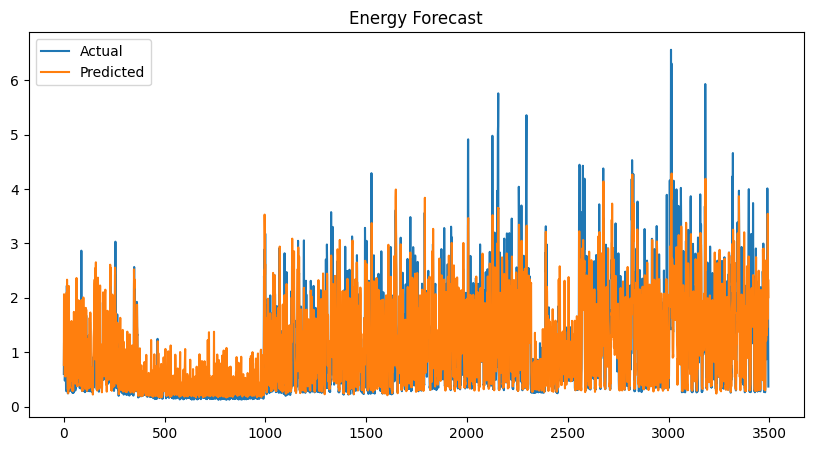

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Energy Forecast")
plt.show()